In [13]:
import sqlite3

In [14]:
conn = sqlite3.connect("sales_data.db")
cur = conn.cursor()

# Create table
cur.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert sample data
sample_data = [
    ('Apple', 10, 0.5),
    ('Banana', 20, 0.3),
    ('Apple', 5, 0.5),
    ('Orange', 8, 0.7),
    ('Banana', 15, 0.3)
]

cur.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()
conn.close()

Sales Summary:
  product  total_qty  revenue
0   Apple         15      7.5
1  Banana         35     10.5
2  Orange          8      5.6


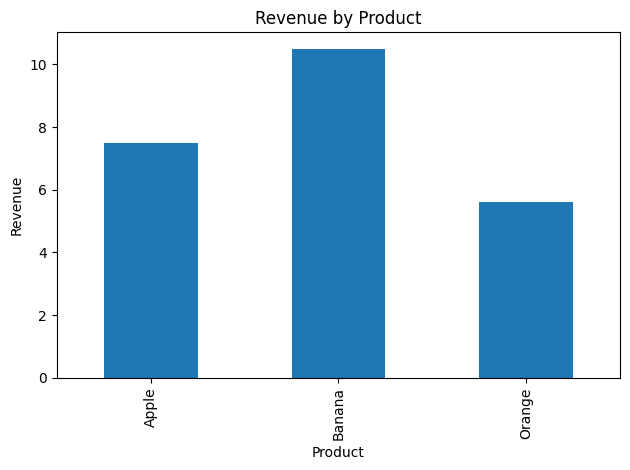

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Connect to SQLite database
conn = sqlite3.connect("sales_data.db")

# SQL query to get total quantity sold and total revenue per product
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""
df = pd.read_sql_query(query, conn)

conn.close()

print("Sales Summary:")
print(df)

# Plot bar chart of revenue per product
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.xlabel("Product")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()